In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("PPG_BP_with_features.csv")

In [8]:
print(df["Hypertension"].unique())

hypertension_map = {
    "Normal": 0,
    "Prehypertension": 1,
    "Stage 1 hypertension": 2,
    "Stage 2 hypertension": 3
}

df["Hypertension"] = df["Hypertension"].map(hypertension_map).astype(int)

['Stage 1 hypertension' 'Prehypertension' 'Normal' 'Stage 2 hypertension']


In [19]:
df["Hypertension"].value_counts()

Hypertension
1    255
0    240
2    102
3     60
Name: count, dtype: int64

In [9]:
drop_cols = [
    "subject_ID",
    "trial",
    "Systolic Blood Pressure(mmHg)",
    "Diastolic Blood Pressure(mmHg)",
    "Hypertension",
    "Diabetes",
    "cerebral infarction",
    "cerebrovascular disease"
]

map = {
    "Male": 0,
    "Female": 1
}
df['Sex(M/F)']= df['Sex(M/F)'].map(map).astype(int)

X = df.drop(columns=drop_cols)

In [10]:
# X.isnull().sum().sort_values(ascending=False)

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
inertia = []

K = range(2,11)

for k in K:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

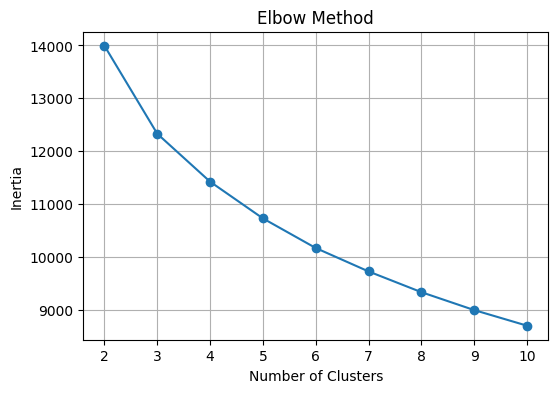

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

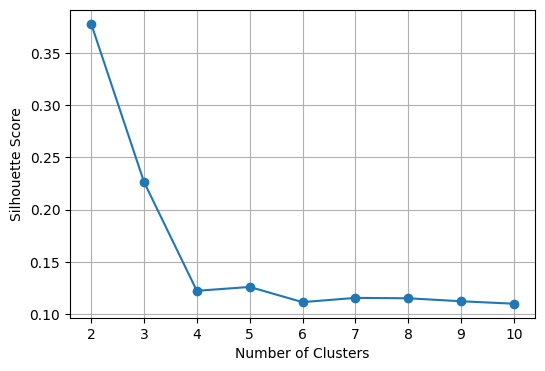

In [14]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(6,4))
plt.plot(range(2,11), scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt
import numpy as np

colors = {
    0: "green",
    1: "orange",
    2: "red",
    3: "purple"
}

labels = {
    0: "Normal",
    1: "Prehypertension",
    2: "Stage 1",
    3: "Stage 2"
}

In [42]:
from sklearn.cluster import KMeans

kmeans2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters2 = kmeans2.fit_predict(X_scaled)

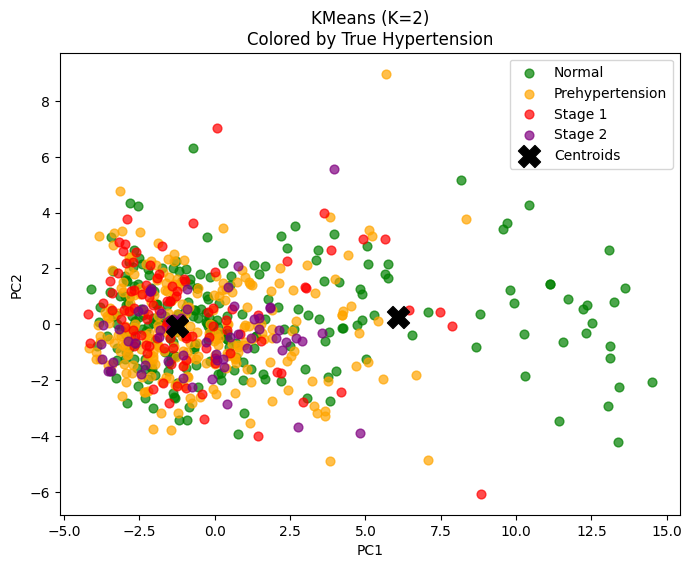

In [43]:
fig, ax = plt.subplots(figsize=(8,6))

# Plot points colored by TRUE hypertension class
for cls in np.unique(df["Hypertension"]):
    mask = df["Hypertension"] == cls

    ax.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        c=colors[cls],
        label=labels[cls],
        s=40,
        alpha=0.7
    )

# Draw cluster boundaries by marking centroids
centroids = pca.transform(kmeans2.cluster_centers_)

ax.scatter(
    centroids[:,0],
    centroids[:,1],
    marker="X",
    s=250,
    c="black",
    label="Centroids"
)

ax.set_title("KMeans (K=2)\nColored by True Hypertension")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()

In [17]:
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)
y_true = df["Hypertension"]

print("ARI:", adjusted_rand_score(y_true, clusters))
print("NMI:", normalized_mutual_info_score(y_true, clusters))

ARI: 0.00592360133675155
NMI: 0.03443434259369105


In [ ]:
plt.figure(figsize=(8,6))

for cls in sorted(df["Hypertension"].unique()):
    mask = df["Hypertension"] == cls
    plt.scatter(
        X_umap[mask,0],
        X_umap[mask,1],
        label=labels[cls],
        alpha=0.7
    )

plt.legend()
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Projection")
plt.show()

In [44]:
kmeans4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

clusters4 = kmeans4.fit_predict(X_scaled)

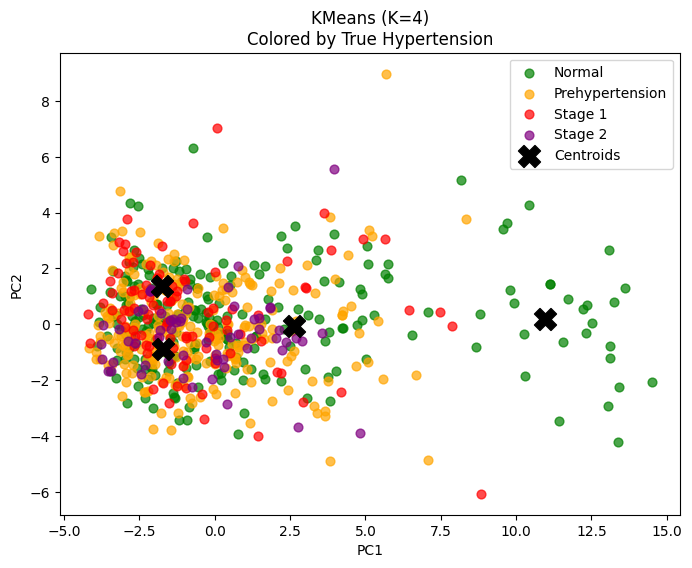

In [45]:
fig, ax = plt.subplots(figsize=(8,6))

for cls in np.unique(df["Hypertension"]):
    mask = df["Hypertension"] == cls

    ax.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        c=colors[cls],
        label=labels[cls],
        s=40,
        alpha=0.7
    )

centroids = pca.transform(kmeans4.cluster_centers_)

ax.scatter(
    centroids[:,0],
    centroids[:,1],
    marker="X",
    s=250,
    c="black",
    label="Centroids"
)

ax.set_title("KMeans (K=4)\nColored by True Hypertension")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

plt.show()

## HIERARCHICHAL CLUSTERING ##

In [49]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'   # try 'complete', 'average', 'single' later
)

clusters = hc.fit_predict(X_scaled)

In [50]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

print("ARI:", adjusted_rand_score(y_true, clusters))
print("NMI:", normalized_mutual_info_score(y_true, clusters))
print("Silhouette:", silhouette_score(X_scaled, clusters))

ARI: -0.005712775714117354
NMI: 0.037558870208585976
Silhouette: 0.22022027278274703


In [51]:
pd.crosstab(
    df["Hypertension"],
    clusters,
    rownames=["True Class"],
    colnames=["Cluster"]
)

Cluster,0,1,2,3
True Class,,,,
0,150,39,28,23
1,183,41,1,30
2,82,12,3,5
3,39,16,0,5


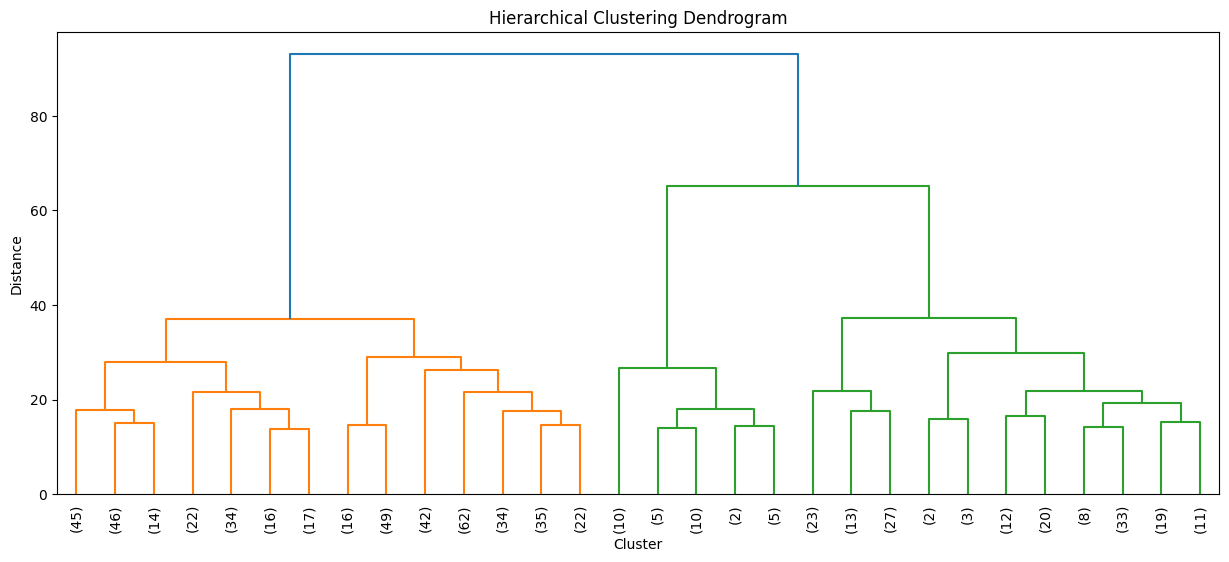

In [53]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(15,6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

In [54]:
for linkage in ["ward", "complete", "average", "single"]:
    
    hc = AgglomerativeClustering(
        n_clusters=4,
        linkage=linkage
    )
    
    clusters = hc.fit_predict(X_scaled)
    
    print(f"\n{linkage.upper()}")
    print("ARI:", adjusted_rand_score(y_true, clusters))
    print("NMI:", normalized_mutual_info_score(y_true, clusters))


WARD
ARI: -0.005712775714117354
NMI: 0.037558870208585976

COMPLETE
ARI: -0.007888473725337766
NMI: 0.03458380702986147

AVERAGE
ARI: -0.0017073066307786752
NMI: 0.04888990292425583

SINGLE
ARI: 0.0019139417966685009
NMI: 0.010451460400286206


## GMM ##

In [18]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)

gmm = GaussianMixture(
    n_components=4,
    covariance_type='full',
    random_state=42,
    n_init=10
)

clusters = gmm.fit_predict(X_scaled)

print("ARI:", adjusted_rand_score(y_true, clusters))
print("NMI:", normalized_mutual_info_score(y_true, clusters))
print("Silhouette:", silhouette_score(X_scaled, clusters))

ARI: -0.00113969293184699
NMI: 0.042209149316160974
Silhouette: 0.11611299444627078


## UNIVARIATE DIAGNOSTIC ##

In [28]:
from scipy import stats
from statsmodels.stats.multitest import multipletests


In [29]:
feature_cols = [
    "mean_ppg", "std_ppg", "skew_ppg", "kurtosis_ppg", "rms_ppg",
    "max_ppg", "min_ppg", "range_ppg", "heart_rate", "mean_peak_amp",
    "std_peak_amp", "mean_peak_distance", "max_vpg", "min_vpg",
    "mean_vpg", "std_vpg", "max_apg", "min_apg", "mean_apg", "std_apg",
    "dominant_freq", "spectral_energy"
]

label_cols = [
    "subject_ID", "Sex(M/F)", "Age(year)", "Height(cm)", "Weight(kg)",
    "Systolic Blood Pressure(mmHg)", "Diastolic Blood Pressure(mmHg)",
    "Heart Rate(b/m)", "BMI(kg/m^2)", "Hypertension"
]

In [30]:
# ---------------------------------------------------------
# Step 1: aggregate 3 rows/subject (trial 1,2,3) into 1 row/subject
# ---------------------------------------------------------
subject_df = df.groupby("subject_ID")[feature_cols].mean().reset_index()

labels = df.drop_duplicates("subject_ID")[label_cols]
subject_df = subject_df.merge(labels, on="subject_ID")

# rename to clean working names used in the rest of this script
subject_df = subject_df.rename(columns={
    "Age(year)": "Age",
    "Height(cm)": "Height",
    "Weight(kg)": "Weight",
    "Systolic Blood Pressure(mmHg)": "SBP",
    "Diastolic Blood Pressure(mmHg)": "DBP",
    "Heart Rate(b/m)": "HR_label",
    "BMI(kg/m^2)": "BMI",
    "Sex(M/F)": "Sex",
})

print(subject_df.shape)          # expect (219, ...)
print(subject_df["Hypertension"].value_counts())  # expect counts for 0,1,2,3




(219, 32)
Hypertension
1    85
0    80
2    34
3    20
Name: count, dtype: int64


In [31]:
# ---------------------------------------------------------
# Step 2: binary group — Normal(0) vs Hypertensive(2,3)
# Prehypertension(1) intentionally excluded -> becomes NaN
# ---------------------------------------------------------
subject_df["BP_binary"] = subject_df["Hypertension"].map({
    0: "Normal",
    2: "Hypertensive",
    3: "Hypertensive",
})
print(subject_df["BP_binary"].value_counts(dropna=False))

BP_binary
NaN             85
Normal          80
Hypertensive    54
Name: count, dtype: int64


In [32]:
# ---------------------------------------------------------
# Step 3: Kruskal-Wallis across all 4 groups (0,1,2,3), per feature
# ---------------------------------------------------------
def kruskal_test_all_features(data, group_col, feats):
    results = []
    groups = data[group_col].dropna().unique()
    for feat in feats:
        vals = [data.loc[data[group_col] == g, feat].dropna().values for g in groups]
        vals = [v for v in vals if len(v) > 1]
        if len(vals) < 2:
            continue
        stat, p = stats.kruskal(*vals)
        n_total = sum(len(v) for v in vals)
        k = len(vals)
        eta_sq = (stat - k + 1) / (n_total - k) if n_total > k else np.nan
        results.append({"feature": feat, "H_stat": stat, "p_value": p,
                         "eta_squared": eta_sq, "n": n_total})
    res = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
    res["p_fdr"] = multipletests(res["p_value"], method="fdr_bh")[1]
    return res

kw_results = kruskal_test_all_features(subject_df, "Hypertension", feature_cols)
print("\n=== Kruskal-Wallis: 4-group ===")
print(kw_results.to_string(index=False))


=== Kruskal-Wallis: 4-group ===
           feature   H_stat  p_value  eta_squared   n    p_fdr
      kurtosis_ppg 9.343763 0.025053     0.029506 219 0.488255
           std_vpg 6.183395 0.103021     0.014806 219 0.488255
           std_apg 5.482820 0.139670     0.011548 219 0.488255
     mean_peak_amp 5.363879 0.147011     0.010995 219 0.488255
           min_ppg 4.616044 0.202170     0.007516 219 0.488255
     dominant_freq 4.517421 0.210742     0.007058 219 0.488255
           min_apg 4.091257 0.251777     0.005076 219 0.488255
         range_ppg 4.064514 0.254582     0.004951 219 0.488255
          skew_ppg 3.952514 0.266638     0.004430 219 0.488255
           max_vpg 3.790904 0.284946     0.003679 219 0.488255
           max_ppg 3.767684 0.287667     0.003571 219 0.488255
           rms_ppg 3.541100 0.315471     0.002517 219 0.488255
   spectral_energy 3.499713 0.320799     0.002324 219 0.488255
mean_peak_distance 3.465351 0.325284     0.002164 219 0.488255
           std_ppg 3.3

In [33]:
# ---------------------------------------------------------
# Step 4: Mann-Whitney U — Normal vs Hypertensive (binary, cleaner contrast)
# ---------------------------------------------------------
def mannwhitney_all_features(data, group_col, feats, group_a, group_b):
    results = []
    for feat in feats:
        a = data.loc[data[group_col] == group_a, feat].dropna().values
        b = data.loc[data[group_col] == group_b, feat].dropna().values
        if len(a) < 2 or len(b) < 2:
            continue
        stat, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        r_rb = 1 - (2 * stat) / (len(a) * len(b))
        results.append({"feature": feat, "U_stat": stat, "p_value": p,
                         "rank_biserial_r": r_rb, "n_a": len(a), "n_b": len(b)})
    res = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
    res["p_fdr"] = multipletests(res["p_value"], method="fdr_bh")[1]
    return res

mw_results = mannwhitney_all_features(subject_df, "BP_binary", feature_cols,
                                       "Normal", "Hypertensive")
print("\n=== Mann-Whitney: Normal vs Hypertensive ===")
print(mw_results.to_string(index=False))


=== Mann-Whitney: Normal vs Hypertensive ===
           feature  U_stat  p_value  rank_biserial_r  n_a  n_b    p_fdr
      kurtosis_ppg  2768.0 0.005857        -0.281481   80   54 0.128856
           std_apg  2467.0 0.164434        -0.142130   80   54 0.596928
     mean_peak_amp  2450.0 0.189116        -0.134259   80   54 0.596928
           max_vpg  2448.0 0.192190        -0.133333   80   54 0.596928
           std_vpg  2437.0 0.209759        -0.128241   80   54 0.596928
           max_ppg  2424.0 0.231985        -0.122222   80   54 0.596928
           min_apg  1904.0 0.246468         0.118519   80   54 0.596928
         range_ppg  2415.0 0.248322        -0.118056   80   54 0.596928
           min_ppg  1917.0 0.271331         0.112500   80   54 0.596928
           max_apg  2403.0 0.271331        -0.112500   80   54 0.596928
        heart_rate  1944.0 0.328308         0.100000   80   54 0.609421
          skew_ppg  2368.0 0.346582        -0.096296   80   54 0.609421
   spectral_energy

In [34]:
# ---------------------------------------------------------
# Step 5: correlation with continuous SBP / DBP
# ---------------------------------------------------------
def correlation_with_target(data, target_col, feats):
    results = []
    for feat in feats:
        x = data[feat].values
        y = data[target_col].values
        mask = ~np.isnan(x) & ~np.isnan(y)
        if mask.sum() < 3:
            continue
        rho, p = stats.spearmanr(x[mask], y[mask])
        results.append({"feature": feat, "spearman_rho": rho, "p_value": p, "n": mask.sum()})
    res = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)
    res["p_fdr"] = multipletests(res["p_value"], method="fdr_bh")[1]
    return res

corr_sbp = correlation_with_target(subject_df, "SBP", feature_cols)
corr_dbp = correlation_with_target(subject_df, "DBP", feature_cols)
print("\n=== vs SBP ===")
print(corr_sbp.to_string(index=False))
print("\n=== vs DBP ===")
print(corr_dbp.to_string(index=False))


# ---------------------------------------------------------
# Step 6: confound check — Age, BMI, Height, Weight
# ---------------------------------------------------------
for target in ["Age", "BMI", "Height", "Weight"]:
    corr_t = correlation_with_target(subject_df, target, feature_cols)
    print(f"\n=== vs {target} (confound check) ===")
    print(corr_t.head(8).to_string(index=False))


=== vs SBP ===
           feature  spearman_rho  p_value   n    p_fdr
      kurtosis_ppg     -0.218307 0.001148 219 0.025258
           std_apg     -0.093042 0.170065 219 0.546864
           max_ppg     -0.089893 0.185051 219 0.546864
           max_apg     -0.089749 0.185759 219 0.546864
      std_peak_amp     -0.083976 0.215790 219 0.546864
           min_apg      0.081532 0.229493 219 0.546864
           max_vpg     -0.080643 0.234628 219 0.546864
           std_vpg     -0.078787 0.245611 219 0.546864
         range_ppg     -0.078379 0.248072 219 0.546864
          skew_ppg     -0.077996 0.250400 219 0.546864
     mean_peak_amp     -0.074329 0.273432 219 0.546864
           min_ppg      0.063948 0.346251 219 0.628786
   spectral_energy     -0.057248 0.399205 219 0.628786
           rms_ppg     -0.055070 0.417418 219 0.628786
           std_ppg     -0.052481 0.439679 219 0.628786
          mean_apg     -0.050485 0.457299 219 0.628786
          mean_ppg     -0.040174 0.554284 219 0.6

In [35]:
!pip install pingouin --break-system-packages


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [38]:
import pingouin as pg  
partial_results = []
for feat in feature_cols:
    sub = subject_df[[feat, "DBP", "BMI", "Age"]].dropna()
    if len(sub) < 10:
        continue
    res = pg.partial_corr(data=sub, x=feat, y="DBP", covar=["BMI", "Age"], method="spearman")
    partial_results.append({
        "feature": feat,
        "partial_rho": res["r"].values[0],
        "p_value": res["p_val"].values[0],
        "n": res["n"].values[0],
    })

partial_df = pd.DataFrame(partial_results).sort_values("p_value").reset_index(drop=True)
partial_df["p_fdr"] = multipletests(partial_df["p_value"], method="fdr_bh")[1]
print(partial_df.to_string(index=False))

           feature  partial_rho  p_value   n    p_fdr
      kurtosis_ppg    -0.198703 0.003287 219 0.031169
           max_ppg    -0.195632 0.003813 219 0.031169
      std_peak_amp    -0.193118 0.004300 219 0.031169
         range_ppg    -0.184151 0.006521 219 0.031169
   spectral_energy    -0.180427 0.007712 219 0.031169
           rms_ppg    -0.174968 0.009808 219 0.031169
           std_ppg    -0.172461 0.010930 219 0.031169
           max_apg    -0.171613 0.011334 219 0.031169
           std_vpg    -0.161962 0.016947 219 0.035133
           min_ppg     0.161904 0.016987 219 0.035133
           max_vpg    -0.161077 0.017567 219 0.035133
           std_apg    -0.157767 0.020061 219 0.036778
     mean_peak_amp    -0.150238 0.026902 219 0.045527
          skew_ppg    -0.145878 0.031713 219 0.049835
          mean_apg    -0.139317 0.040324 219 0.059141
mean_peak_distance    -0.132362 0.051520 219 0.070840
           min_vpg     0.124075 0.068117 219 0.088151
        heart_rate     0.115

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# features that survived the partial correlation check
selected_feats = [
    "kurtosis_ppg", "max_ppg", "std_peak_amp", "range_ppg", "spectral_energy",
    "rms_ppg", "std_ppg", "max_apg", "std_vpg", "min_ppg", "max_vpg",
    "std_apg", "mean_peak_amp"
]

data = subject_df[selected_feats + ["BMI", "Age", "DBP"]].dropna()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Baseline model: BMI + Age only
X_baseline = data[["BMI", "Age"]].values
y = data["DBP"].values
r2_baseline = cross_val_score(LinearRegression(), X_baseline, y, cv=kf, scoring="r2")

# Full model: BMI + Age + PPG features
X_full = data[["BMI", "Age"] + selected_feats].values
r2_full = cross_val_score(LinearRegression(), X_full, y, cv=kf, scoring="r2")

print(f"Baseline (BMI+Age only) R²: {r2_baseline.mean():.3f} ± {r2_baseline.std():.3f}")
print(f"Full (BMI+Age+PPG feats) R²: {r2_full.mean():.3f} ± {r2_full.std():.3f}")

Baseline (BMI+Age only) R²: 0.010 ± 0.035
Full (BMI+Age+PPG feats) R²: -0.010 ± 0.080


: 